# UNO Vision Pipeline

End-to-end notebook for the current repo state.

It uses the surviving source code to:
- detect binary symbol patches and their image centers,
- classify each symbol with the trained CNN,
- assign detected symbols/cards to center table or players,
- detect the token center and infer the active player,
- generate a Kaggle-style submission CSV.

Assumptions used by this notebook:
- `p1` is bottom, `p2` is right, `p3` is top, `p4` is left.
- player id `0` is the center/table card cluster.
- black special labels `wild` and `draw_4` are written without a color prefix.
- colored labels are written as `b_5`, `g_reverse`, etc.

In [1]:
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import csv
import sys
import threading

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageOps
from torchvision import transforms

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "iapr-26-uno-vision-challenge").exists():
    PROJECT_DIR = PROJECT_DIR / "project"

SEGMENTATION_DIR = PROJECT_DIR / "segmentation"
CLASSIFIER_DIR = PROJECT_DIR / "symbol_classification"
for path in (PROJECT_DIR, SEGMENTATION_DIR, CLASSIFIER_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import segmentation
from cards_to_players_utils import clustering, cluster_2_player_mapping
from train_cnn import IMAGE_SIZE, DEFAULT_OUTPUT_PATH, load_model

DATA_DIR = PROJECT_DIR / "iapr-26-uno-vision-challenge"
TRAIN_IMAGES_DIR = DATA_DIR / "train_images"
TEST_IMAGES_DIR = DATA_DIR / "test_images"
OUTPUT_SUBMISSION_PATH = PROJECT_DIR / "submission_pipeline.csv"

torch.backends.cudnn.benchmark = True

PREFER_CPU_SEGMENTATION = True
PIPELINE_WORKERS = 8

acceleration_backend = "cpu" if PREFER_CPU_SEGMENTATION else segmentation.configure_acceleration()
segmentation.set_acceleration_backend(acceleration_backend)

print(f"Project dir: {PROJECT_DIR}")
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"PyTorch GPU: {torch.cuda.get_device_name(0)}")
print(f"OpenCV segmentation backend: {acceleration_backend}")
print(f"Pipeline workers: {PIPELINE_WORKERS}")
print(f"OpenCV CUDA devices: {cv2.cuda.getCudaEnabledDeviceCount() if hasattr(cv2, 'cuda') else 0}")
print(f"OpenCV OpenCL available: {cv2.ocl.haveOpenCL()}")

Project dir: c:\Users\ayoub\Code\IAPR_gr69\project
PyTorch CUDA available: True
PyTorch GPU: NVIDIA GeForce RTX 3090 Ti
OpenCV segmentation backend: cpu
Pipeline workers: 8
OpenCV CUDA devices: 0
OpenCV OpenCL available: True


## Load Symbol Classifier

In [2]:
if not torch.cuda.is_available():
    raise RuntimeError("PyTorch CUDA is not available in this notebook kernel. Use the iapr environment with torch+cu128.")

device = torch.device("cuda")
model, checkpoint, device = load_model(DEFAULT_OUTPUT_PATH, device)
model = model.to(device)
model.eval()
idx_to_class = checkpoint["idx_to_class"]
print(f"Classifier device: {device}")
print(f"Checkpoint validation accuracy: {checkpoint.get('val_acc', 'unknown')}")
print(f"Classes: {list(idx_to_class.values())}")

symbol_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((checkpoint.get("image_size", IMAGE_SIZE),) * 2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,)),
])
CLASSIFIER_LOCK = threading.Lock()

def classify_symbol_patch(symbol_patch):
    image = Image.fromarray(np.asarray(symbol_patch)).convert("L")
    tensor = symbol_transform(ImageOps.autocontrast(image)).unsqueeze(0).to(device)
    with CLASSIFIER_LOCK, torch.no_grad():
        probabilities = torch.softmax(model(tensor), dim=1)[0]
    confidence, class_idx = probabilities.max(dim=0)
    return idx_to_class[int(class_idx)], float(confidence)

def classify_symbol_patches(symbol_patches):
    if not symbol_patches:
        return []
    tensors = []
    for symbol_patch in symbol_patches:
        image = Image.fromarray(np.asarray(symbol_patch)).convert("L")
        tensors.append(symbol_transform(ImageOps.autocontrast(image)))
    batch = torch.stack(tensors, dim=0).to(device, non_blocking=True)
    with CLASSIFIER_LOCK, torch.no_grad():
        probabilities = torch.softmax(model(batch), dim=1)
    confidences, class_indices = probabilities.max(dim=1)
    return [
        (idx_to_class[int(class_idx)], float(confidence))
        for class_idx, confidence in zip(class_indices.cpu(), confidences.cpu())
    ]

Classifier device: cuda
Checkpoint validation accuracy: 0.9982142857142857
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'draw_2', 'draw_4', 'reverse', 'skip', 'wild']


## Geometry Helpers

In [3]:
PLAYER_ID_TO_NAME = {
    1: "p1",
    2: "p2",
    3: "p3",
    4: "p4",
}

PLAYER_ID_TO_COLUMN = {
    1: "player_1_cards",
    2: "player_2_cards",
    3: "player_3_cards",
    4: "player_4_cards",
}

COLOR_PREFIX = {
    "blue": "b",
    "green": "g",
    "red": "r",
    "yellow": "y",
    "black": "black",
}

def player_anchor_positions(width, height, buffer=200):
    return np.array([
        [width // 2, height // 2],
        [width // 2, height - buffer],
        [width - buffer, height // 2],
        [width // 2, buffer],
        [buffer, height // 2],
    ], dtype=np.float32)

def active_player_from_token(token_center, width, height, buffer=200):
    if token_center is None:
        return "EMPTY"
    anchors = player_anchor_positions(width, height, buffer=buffer)[1:]
    distances = np.linalg.norm(anchors - np.asarray(token_center, dtype=np.float32), axis=1)
    player_id = int(np.argmin(distances)) + 1
    return PLAYER_ID_TO_NAME[player_id]

def card_string(color, symbol_label):
    if symbol_label in {"wild", "draw_4"}:
        return symbol_label
    prefix = COLOR_PREFIX.get(color, color)
    if prefix == "black":
        return symbol_label
    return f"{prefix}_{symbol_label}"

def sort_cards_for_player(records, player_id):
    if player_id == 1:
        return sorted(records, key=lambda row: (row["center"][0], row["center"][1]))
    if player_id == 2:
        return sorted(records, key=lambda row: (row["center"][1], row["center"][0]))
    if player_id == 3:
        return sorted(records, key=lambda row: (row["center"][0], row["center"][1]))
    if player_id == 4:
        return sorted(records, key=lambda row: (row["center"][1], row["center"][0]))
    return records

def empty_or_join(cards):
    return ";".join(cards) if cards else "EMPTY"

def cards_with_detection_pair_collapse(records):
    grouped_records = defaultdict(list)
    for order, record in enumerate(records):
        grouped_records[record["card"]].append((order, record))

    kept_records = []
    for card_records_with_order in grouped_records.values():
        card_records = [record for _, record in card_records_with_order]
        keep_count = (len(card_records) + 1) // 2
        kept_records.extend(card_records_with_order[:keep_count])
        for _, record in card_records_with_order[:keep_count]:
            record["kept_in_hand"] = True
        for _, record in card_records_with_order[keep_count:]:
            record["kept_in_hand"] = False

    kept_records.sort(key=lambda item: item[0])
    return [record["card"] for _, record in kept_records]

## One Image Pipeline

In [4]:
def detect_and_classify_symbols(image_rgb):
    detected = segmentation.detect_symbols(Image.fromarray(image_rgb))
    predictions = classify_symbol_patches([patch for patch, _, _ in detected])
    records = []
    for (patch, color, center), (symbol_label, confidence) in zip(detected, predictions):
        records.append({
            "patch": patch,
            "color": color,
            "symbol": symbol_label,
            "card": card_string(color, symbol_label),
            "center": tuple(float(value) for value in center),
            "confidence": confidence,
        })
    return records

def assign_players(records, width, height, eps=600, buffer=200):
    if not records:
        return records
    points = np.array([row["center"] for row in records], dtype=np.float32)
    cluster_centers, cluster_labels = clustering(points, eps=eps, min_samples=1)
    player_ids = cluster_2_player_mapping(cluster_centers, cluster_labels, width, height, buffer=buffer)
    for row, cluster_label, player_id in zip(records, cluster_labels, player_ids):
        row["cluster"] = int(cluster_label)
        row["player_id"] = int(player_id) if player_id is not None else None
    return records

def prediction_row_for_image(image_path, eps=600, buffer=200):
    image = Image.open(image_path).convert("RGB")
    image_rgb = np.asarray(image)
    height, width = image_rgb.shape[:2]

    records = detect_and_classify_symbols(image_rgb)
    records = assign_players(records, width, height, eps=eps, buffer=buffer)

    token_center = segmentation.get_token_center(image)
    active_player = active_player_from_token(token_center, width, height, buffer=buffer)

    grouped = defaultdict(list)
    for record in records:
        player_id = record.get("player_id")
        if player_id is not None:
            record["kept_in_hand"] = True
            grouped[player_id].append(record)

    center_records = sorted(grouped.get(0, []), key=lambda record: record["confidence"], reverse=True)
    for idx, record in enumerate(center_records):
        record["kept_in_hand"] = idx == 0
    center_card = center_records[0]["card"] if center_records else "EMPTY"

    row = {
        "image_id": image_path.stem,
        "center_card": center_card,
        "active_player": active_player,
        "player_1_cards": "EMPTY",
        "player_2_cards": "EMPTY",
        "player_3_cards": "EMPTY",
        "player_4_cards": "EMPTY",
    }

    for player_id, column in PLAYER_ID_TO_COLUMN.items():
        player_records = sort_cards_for_player(grouped.get(player_id, []), player_id)
        cards = cards_with_detection_pair_collapse(player_records)
        row[column] = empty_or_join(cards)

    debug = {
        "image_rgb": image_rgb,
        "records": records,
        "token_center": token_center,
        "width": width,
        "height": height,
    }
    return row, debug

## Visual Debug On One Image

In [5]:
image_path = next(TEST_IMAGES_DIR.glob("*.jpg"))
# image_path = TRAIN_IMAGES_DIR / "L1000770.jpg"
row, debug = prediction_row_for_image(image_path)
row

{'image_id': 'L1000793',
 'center_card': 'g_0',
 'active_player': 'p2',
 'player_1_cards': 'EMPTY',
 'player_2_cards': 'r_reverse;r_6;g_4',
 'player_3_cards': 'b_6;y_5;r_9',
 'player_4_cards': 'r_5;y_0;g_5'}

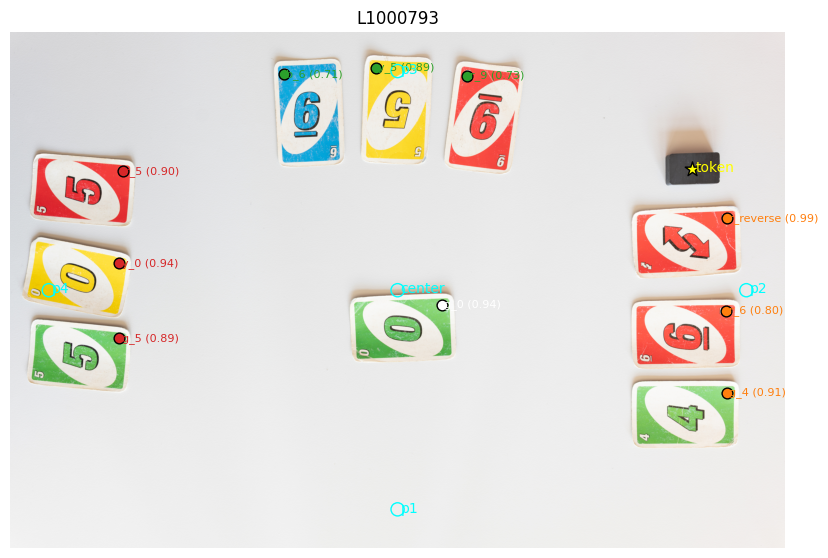

In [6]:
def show_debug(debug, row=None):
    image = debug["image_rgb"].copy()
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(image)
    ax.set_title(row["image_id"] if row else "pipeline debug")

    colors = {0: "white", 1: "tab:blue", 2: "tab:orange", 3: "tab:green", 4: "tab:red"}
    for record in debug["records"]:
        if record.get("player_id") in PLAYER_ID_TO_COLUMN and not record.get("kept_in_hand", True):
            continue
        if record.get("player_id") == 0 and not record.get("kept_in_hand", True):
            continue
        x, y = record["center"]
        player_id = record.get("player_id")
        color = colors.get(player_id, "magenta")
        ax.scatter([x], [y], s=60, c=color, edgecolors="black")
        ax.text(x + 12, y + 12, f"{record['card']} ({record['confidence']:.2f})", color=color, fontsize=8)

    token_center = debug.get("token_center")
    if token_center is not None:
        ax.scatter([token_center[0]], [token_center[1]], s=120, c="yellow", edgecolors="black", marker="*")
        ax.text(token_center[0] + 16, token_center[1] + 16, "token", color="yellow", fontsize=10)

    anchors = player_anchor_positions(debug["width"], debug["height"])
    for idx, (x, y) in enumerate(anchors):
        label = "center" if idx == 0 else f"p{idx}"
        ax.scatter([x], [y], s=90, c="none", edgecolors="cyan")
        ax.text(x + 16, y + 16, label, color="cyan", fontsize=10)

    ax.set_axis_off()
    plt.show()

show_debug(debug, row)

## Compare On A Training Image With Ground Truth

In [7]:
train_csv_path = DATA_DIR / "train.csv"
with open(train_csv_path, newline="") as f:
    train_rows = list(csv.DictReader(f))
train_image_path = TRAIN_IMAGES_DIR / f"{train_rows[0]['image_id']}.jpg"
pred_row, train_debug = prediction_row_for_image(train_image_path)
truth_row = train_rows[0]
print("truth")
print(truth_row)
print("\nprediction")
print(pred_row)

truth
{'image_id': 'L1000770', 'center_card': 'y_1', 'active_player': 'p3', 'player_1_cards': 'EMPTY', 'player_2_cards': 'y_4;g_2;r_3', 'player_3_cards': 'r_skip;y_2;b_5', 'player_4_cards': 'EMPTY'}

prediction
{'image_id': 'L1000770', 'center_card': 'y_1', 'active_player': 'p3', 'player_1_cards': 'EMPTY', 'player_2_cards': 'r_3;g_2;y_4', 'player_3_cards': 'b_5;y_2;r_skip', 'player_4_cards': 'EMPTY'}


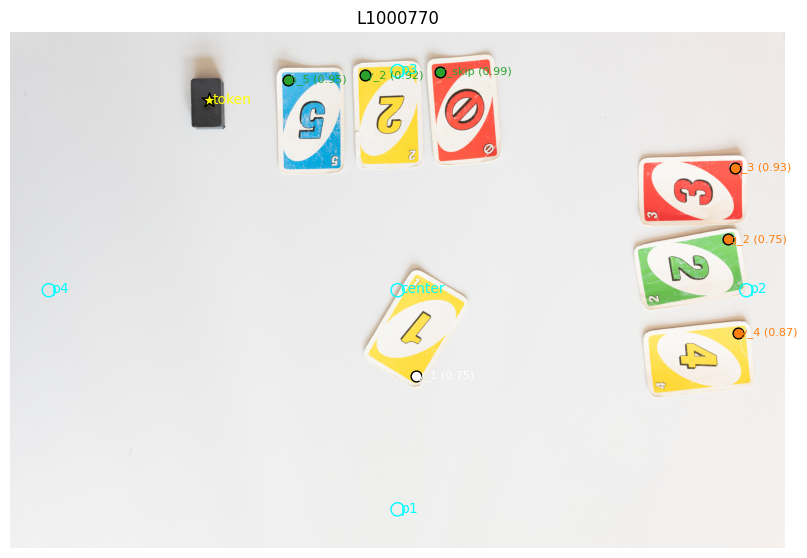

In [8]:
show_debug(train_debug, pred_row)

## Generate Submission

In [9]:
def progress_iter(iterable, total=None, desc="processing"):
    if tqdm is not None:
        yield from tqdm(iterable, total=total, desc=desc)
        return
    for idx, item in enumerate(iterable, start=1):
        if idx == 1 or idx == total or idx % 10 == 0:
            print(f"{desc}: {idx}/{total}")
        yield item

SUBMISSION_COLUMNS = [
    "image_id",
    "center_card",
    "active_player",
    "player_1_cards",
    "player_2_cards",
    "player_3_cards",
    "player_4_cards",
]

def generate_submission(image_dir=TEST_IMAGES_DIR, output_path=OUTPUT_SUBMISSION_PATH, limit=None, workers=PIPELINE_WORKERS):
    image_ids = [path.stem for path in sorted(image_dir.glob("*.jpg"))]
    if limit is not None:
        image_ids = image_ids[:limit]

    def process_image_id(image_id):
        image_path = image_dir / f"{image_id}.jpg"
        try:
            row, _ = prediction_row_for_image(image_path)
            return row, None
        except Exception as exc:
            row = {
                "image_id": image_id,
                "center_card": "EMPTY",
                "active_player": "EMPTY",
                "player_1_cards": "EMPTY",
                "player_2_cards": "EMPTY",
                "player_3_cards": "EMPTY",
                "player_4_cards": "EMPTY",
            }
            return row, (image_id, repr(exc))

    rows = []
    failures = []
    if workers <= 1:
        results = [process_image_id(image_id) for image_id in progress_iter(image_ids, total=len(image_ids), desc="submission")]
    else:
        with ThreadPoolExecutor(max_workers=workers) as executor:
            mapped = executor.map(process_image_id, image_ids)
            results = list(progress_iter(mapped, total=len(image_ids), desc="submission"))

    for row, failure in results:
        rows.append(row)
        if failure is not None:
            failures.append(failure)

    with open(output_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=SUBMISSION_COLUMNS, quoting=csv.QUOTE_MINIMAL)
        writer.writeheader()
        writer.writerows(rows)
    print(f"Saved {len(rows)} rows to {output_path}")
    if failures:
        print(f"Failures: {len(failures)}")
        print(failures[:10])
    return rows, failures

# Start with a small smoke test. Set limit=None for the full test set.
submission_preview, failures = generate_submission(limit=5)
submission_preview[:5]

submission:   0%|          | 0/5 [00:00<?, ?it/s]

Saved 5 rows to c:\Users\ayoub\Code\IAPR_gr69\project\submission_pipeline.csv


[{'image_id': 'L1000793',
  'center_card': 'g_0',
  'active_player': 'p2',
  'player_1_cards': 'EMPTY',
  'player_2_cards': 'r_reverse;r_6;g_4',
  'player_3_cards': 'b_6;y_5;r_9',
  'player_4_cards': 'r_5;y_0;g_5'},
 {'image_id': 'L1000794',
  'center_card': 'EMPTY',
  'active_player': 'p1',
  'player_1_cards': 'y_9;r_skip',
  'player_2_cards': 'EMPTY',
  'player_3_cards': 'r_2;g_7;y_7;b_0',
  'player_4_cards': 'EMPTY'},
 {'image_id': 'L1000795',
  'center_card': 'EMPTY',
  'active_player': 'p1',
  'player_1_cards': 'wild;r_skip;y_8;g_2',
  'player_2_cards': 'EMPTY',
  'player_3_cards': 'EMPTY',
  'player_4_cards': 'y_0;b_1;draw_4;r_5'},
 {'image_id': 'L1000796',
  'center_card': 'b_skip',
  'active_player': 'p1',
  'player_1_cards': 'EMPTY',
  'player_2_cards': 'wild;g_1;g_draw_2',
  'player_3_cards': 'EMPTY',
  'player_4_cards': 'r_5;g_6'},
 {'image_id': 'L1000797',
  'center_card': 'y_0',
  'active_player': 'p2',
  'player_1_cards': 'EMPTY',
  'player_2_cards': 'r_1;y_5',
  'player_

In [10]:
# Full submission:
submission, failures = generate_submission(limit=None)
submission[:5]

submission:   0%|          | 0/159 [00:00<?, ?it/s]

Saved 159 rows to c:\Users\ayoub\Code\IAPR_gr69\project\submission_pipeline.csv


[{'image_id': 'L1000793',
  'center_card': 'g_0',
  'active_player': 'p2',
  'player_1_cards': 'EMPTY',
  'player_2_cards': 'r_reverse;r_6;g_4',
  'player_3_cards': 'b_6;y_5;r_9',
  'player_4_cards': 'r_5;y_0;g_5'},
 {'image_id': 'L1000794',
  'center_card': 'EMPTY',
  'active_player': 'p1',
  'player_1_cards': 'y_9;r_skip',
  'player_2_cards': 'EMPTY',
  'player_3_cards': 'r_2;g_7;y_7;b_0',
  'player_4_cards': 'EMPTY'},
 {'image_id': 'L1000795',
  'center_card': 'EMPTY',
  'active_player': 'p1',
  'player_1_cards': 'wild;r_skip;y_8;g_2',
  'player_2_cards': 'EMPTY',
  'player_3_cards': 'EMPTY',
  'player_4_cards': 'y_0;b_1;draw_4;r_5'},
 {'image_id': 'L1000796',
  'center_card': 'b_skip',
  'active_player': 'p1',
  'player_1_cards': 'EMPTY',
  'player_2_cards': 'wild;g_1;g_draw_2',
  'player_3_cards': 'EMPTY',
  'player_4_cards': 'r_5;g_6'},
 {'image_id': 'L1000797',
  'center_card': 'y_0',
  'active_player': 'p2',
  'player_1_cards': 'EMPTY',
  'player_2_cards': 'r_1;y_5',
  'player_